In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print("Loss Fonksiyonlarının Olasılıksal Temeli")
print("=" * 45)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. MSE neden (y - ŷ)² — neden küp veya mutlak değil?")
print("2. Cross Entropy neden -log(p) — nereden geliyor?")
print("3. Binary vs Categorical Cross Entropy farkı nedir?")
print("4. Focal Loss nedir, sınıf dengesizliğinde neden kullanılır?")
print("5. Hangi problemde hangi loss kullanılır?")
print()
print("Anahtar kavram: Maximum Likelihood Estimation (MLE)")

Loss Fonksiyonlarının Olasılıksal Temeli

Bugün cevaplayacağımız sorular:
1. MSE neden (y - ŷ)² — neden küp veya mutlak değil?
2. Cross Entropy neden -log(p) — nereden geliyor?
3. Binary vs Categorical Cross Entropy farkı nedir?
4. Focal Loss nedir, sınıf dengesizliğinde neden kullanılır?
5. Hangi problemde hangi loss kullanılır?

Anahtar kavram: Maximum Likelihood Estimation (MLE)


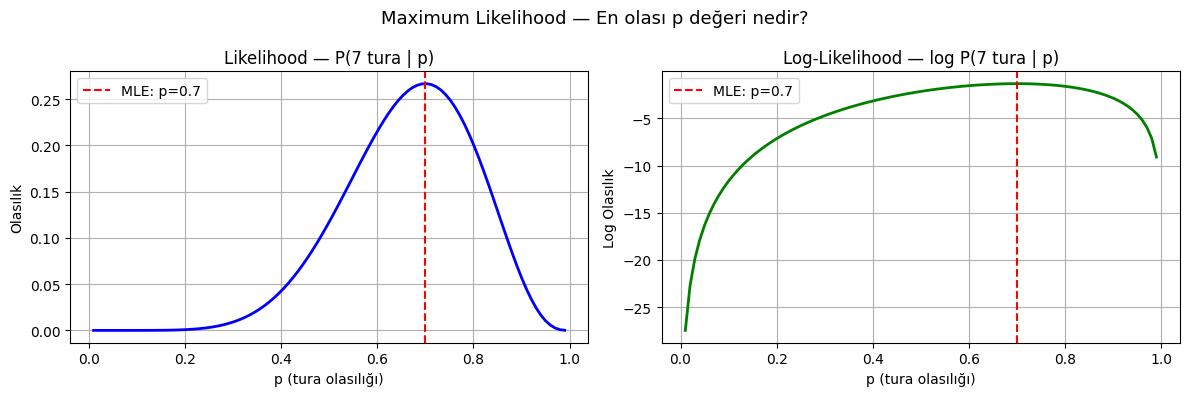

MLE tahmini: p = 0.7
Sezgi: 7/10 = 0.7 — en basit cevap!

Önemli: log(likelihood) maksimize etmek = likelihood maksimize etmek
Çünkü log monoton artan bir fonksiyon.
Ama log ile çalışmak matematiksel olarak çok daha kolay!


In [2]:
# MAXIMUM LIKELIHOOD ESTIMATION (MLE) — Temel Sezgi
#
# Soru: Elimdeki veriyi en iyi açıklayan parametreler neler?
# Cevap: Verinin olasılığını maksimize eden parametreler!
#
# Örnek: 10 yazı tura attın, 7 tura geldi.
# p (tura olasılığı) nedir?

from scipy.stats import binom
import matplotlib.pyplot as plt
import numpy as np

n = 10  # atış sayısı
k = 7   # tura sayısı

p_values = np.linspace(0.01, 0.99, 100)
likelihood = binom.pmf(k, n, p_values)
log_likelihood = np.log(likelihood)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(p_values, likelihood, 'b-', linewidth=2)
axes[0].axvline(x=k/n, color='red', linestyle='--',
                label=f'MLE: p={k/n}')
axes[0].set_title("Likelihood — P(7 tura | p)")
axes[0].set_xlabel("p (tura olasılığı)")
axes[0].set_ylabel("Olasılık")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(p_values, log_likelihood, 'g-', linewidth=2)
axes[1].axvline(x=k/n, color='red', linestyle='--',
                label=f'MLE: p={k/n}')
axes[1].set_title("Log-Likelihood — log P(7 tura | p)")
axes[1].set_xlabel("p (tura olasılığı)")
axes[1].set_ylabel("Log Olasılık")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Maximum Likelihood — En olası p değeri nedir?", fontsize=13)
plt.tight_layout()
plt.show()

print(f"MLE tahmini: p = {k/n}")
print(f"Sezgi: {k}/{n} = {k/n} — en basit cevap!")
print(f"\nÖnemli: log(likelihood) maksimize etmek = likelihood maksimize etmek")
print(f"Çünkü log monoton artan bir fonksiyon.")
print(f"Ama log ile çalışmak matematiksel olarak çok daha kolay!")

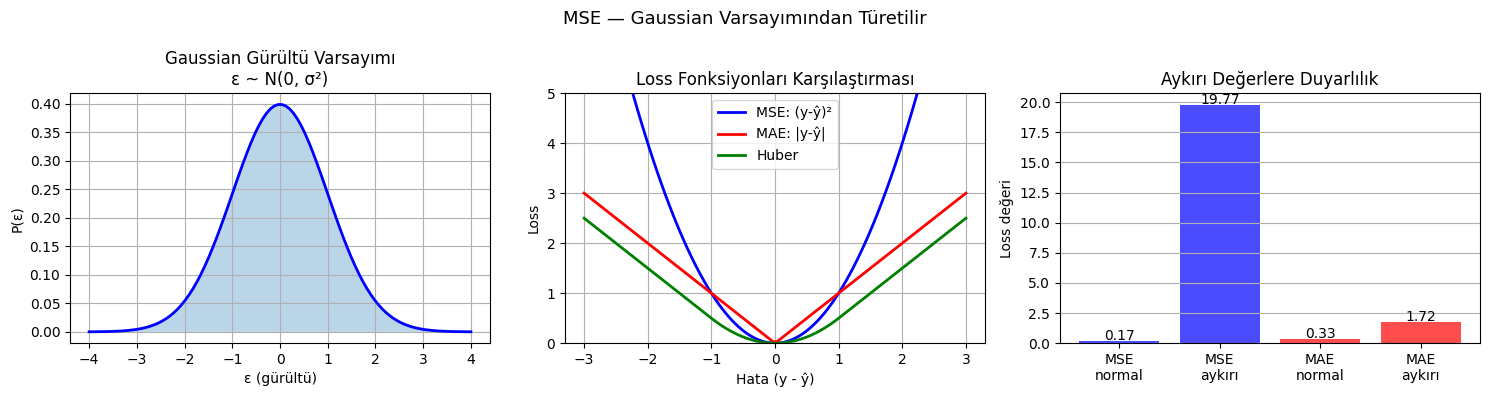

MSE → Gaussian gürültü varsayımı → regresyon
MAE → Laplace gürültü varsayımı → aykırı değerlere dayanıklı
Huber → MSE + MAE kombinasyonu → en iyi iki dünya


In [3]:
# MSE NEREDEN GELİYOR?
#
# Varsayım: Gürültü Gaussian dağılımlı
# y = f(x) + ε,  ε ~ N(0, σ²)
#
# Yani: P(y | x, w) = N(y; ŷ, σ²)
#
# Log-likelihood:
# log P(y|x,w) = -n/2 * log(2πσ²) - 1/(2σ²) * Σ(y - ŷ)²
#
# Maksimize etmek = Σ(y - ŷ)² minimize etmek = MSE!

x_range = np.linspace(-4, 4, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gaussian dağılım
axes[0].plot(x_range, norm.pdf(x_range, 0, 1), 'b-', linewidth=2)
axes[0].fill_between(x_range, norm.pdf(x_range, 0, 1), alpha=0.3)
axes[0].set_title("Gaussian Gürültü Varsayımı\nε ~ N(0, σ²)")
axes[0].set_xlabel("ε (gürültü)")
axes[0].set_ylabel("P(ε)")
axes[0].grid(True)

# MSE vs MAE vs Huber
hata = np.linspace(-3, 3, 100)
mse = hata**2
mae = np.abs(hata)
huber = np.where(np.abs(hata) <= 1,
                 0.5 * hata**2,
                 np.abs(hata) - 0.5)

axes[1].plot(hata, mse, 'b-', linewidth=2, label='MSE: (y-ŷ)²')
axes[1].plot(hata, mae, 'r-', linewidth=2, label='MAE: |y-ŷ|')
axes[1].plot(hata, huber, 'g-', linewidth=2, label='Huber')
axes[1].set_title("Loss Fonksiyonları Karşılaştırması")
axes[1].set_xlabel("Hata (y - ŷ)")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 5)

# Aykırı değerlere duyarlılık
np.random.seed(42)
y_true = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
y_pred = y_true + np.random.randn(10) * 0.5
y_pred_outlier = y_pred.copy()
y_pred_outlier[5] = 20  # Aykırı değer

mse_normal = np.mean((y_true - y_pred)**2)
mse_outlier = np.mean((y_true - y_pred_outlier)**2)
mae_normal = np.mean(np.abs(y_true - y_pred))
mae_outlier = np.mean(np.abs(y_true - y_pred_outlier))

x_pos = [0, 1, 2, 3]
değerler = [mse_normal, mse_outlier, mae_normal, mae_outlier]
renkler_bar = ['blue', 'blue', 'red', 'red']
etiketler = ['MSE\nnormal', 'MSE\naykırı', 'MAE\nnormal', 'MAE\naykırı']

bars = axes[2].bar(x_pos, değerler, color=renkler_bar, alpha=0.7)
axes[2].set_title("Aykırı Değerlere Duyarlılık")
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(etiketler)
axes[2].set_ylabel("Loss değeri")
for bar, val in zip(bars, değerler):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=10)
axes[2].grid(True, axis='y')

plt.suptitle("MSE — Gaussian Varsayımından Türetilir", fontsize=13)
plt.tight_layout()
plt.show()

print("MSE → Gaussian gürültü varsayımı → regresyon")
print("MAE → Laplace gürültü varsayımı → aykırı değerlere dayanıklı")
print("Huber → MSE + MAE kombinasyonu → en iyi iki dünya")

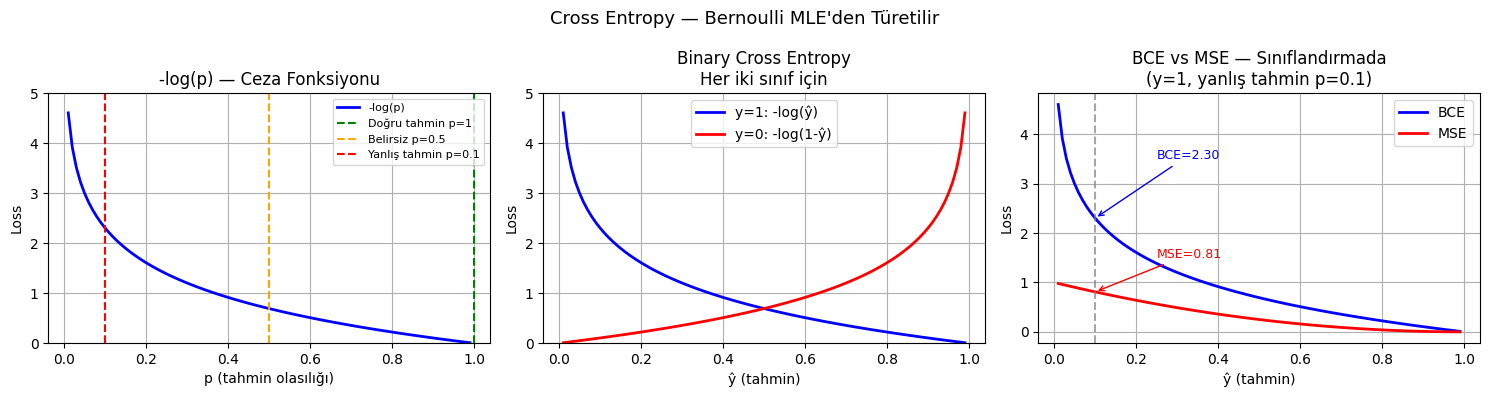

Gerçek sınıf y=1, tahmin ŷ=0.1 (çok yanlış) için:
BCE cezası: 2.3026 — çok büyük!
MSE cezası: 0.8100 — küçük kalıyor

Bu yüzden sınıflandırmada BCE kullanılır!
Yanlış tahmine çok daha sert ceza veriyor.


In [4]:
# CROSS ENTROPY NEREDEN GELİYOR?
#
# Varsayım: Çıktı Bernoulli dağılımlı (0 veya 1)
# P(y=1 | x) = ŷ
# P(y=0 | x) = 1 - ŷ
#
# Tek formülde: P(y | x) = ŷ^y * (1-ŷ)^(1-y)
#
# Log-likelihood:
# log P = y*log(ŷ) + (1-y)*log(1-ŷ)
#
# Negatif log-likelihood = Binary Cross Entropy!
# BCE = -[y*log(ŷ) + (1-y)*log(1-ŷ)]

p = np.linspace(0.01, 0.99, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# -log(p) fonksiyonu
axes[0].plot(p, -np.log(p), 'b-', linewidth=2, label='-log(p)')
axes[0].axvline(x=1.0, color='green', linestyle='--', label='Doğru tahmin p=1')
axes[0].axvline(x=0.5, color='orange', linestyle='--', label='Belirsiz p=0.5')
axes[0].axvline(x=0.1, color='red', linestyle='--', label='Yanlış tahmin p=0.1')
axes[0].set_title("-log(p) — Ceza Fonksiyonu")
axes[0].set_xlabel("p (tahmin olasılığı)")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 5)
axes[0].grid(True)

# BCE — y=1 ve y=0 için
axes[1].plot(p, -np.log(p), 'b-', linewidth=2, label='y=1: -log(ŷ)')
axes[1].plot(p, -np.log(1-p), 'r-', linewidth=2, label='y=0: -log(1-ŷ)')
axes[1].set_title("Binary Cross Entropy\nHer iki sınıf için")
axes[1].set_xlabel("ŷ (tahmin)")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].set_ylim(0, 5)
axes[1].grid(True)

# BCE vs MSE karşılaştırması — sınıflandırmada
y_true_cls = 1  # gerçek sınıf
tahminler = np.linspace(0.01, 0.99, 100)

bce = -(y_true_cls * np.log(tahminler) +
        (1-y_true_cls) * np.log(1-tahminler))
mse_cls = (y_true_cls - tahminler)**2

axes[2].plot(tahminler, bce, 'b-', linewidth=2, label='BCE')
axes[2].plot(tahminler, mse_cls, 'r-', linewidth=2, label='MSE')
axes[2].axvline(x=0.1, color='gray', linestyle='--', alpha=0.7)
axes[2].set_title("BCE vs MSE — Sınıflandırmada\n(y=1, yanlış tahmin p=0.1)")
axes[2].set_xlabel("ŷ (tahmin)")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(True)

bce_01 = -(np.log(0.1))
mse_01 = (1-0.1)**2
axes[2].annotate(f'BCE={bce_01:.2f}', xy=(0.1, bce_01),
                xytext=(0.25, 3.5), fontsize=9, color='blue',
                arrowprops=dict(arrowstyle='->', color='blue'))
axes[2].annotate(f'MSE={mse_01:.2f}', xy=(0.1, mse_01),
                xytext=(0.25, 1.5), fontsize=9, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

plt.suptitle("Cross Entropy — Bernoulli MLE'den Türetilir", fontsize=13)
plt.tight_layout()
plt.show()

print("Gerçek sınıf y=1, tahmin ŷ=0.1 (çok yanlış) için:")
print(f"BCE cezası: {bce_01:.4f} — çok büyük!")
print(f"MSE cezası: {mse_01:.4f} — küçük kalıyor")
print("\nBu yüzden sınıflandırmada BCE kullanılır!")
print("Yanlış tahmine çok daha sert ceza veriyor.")

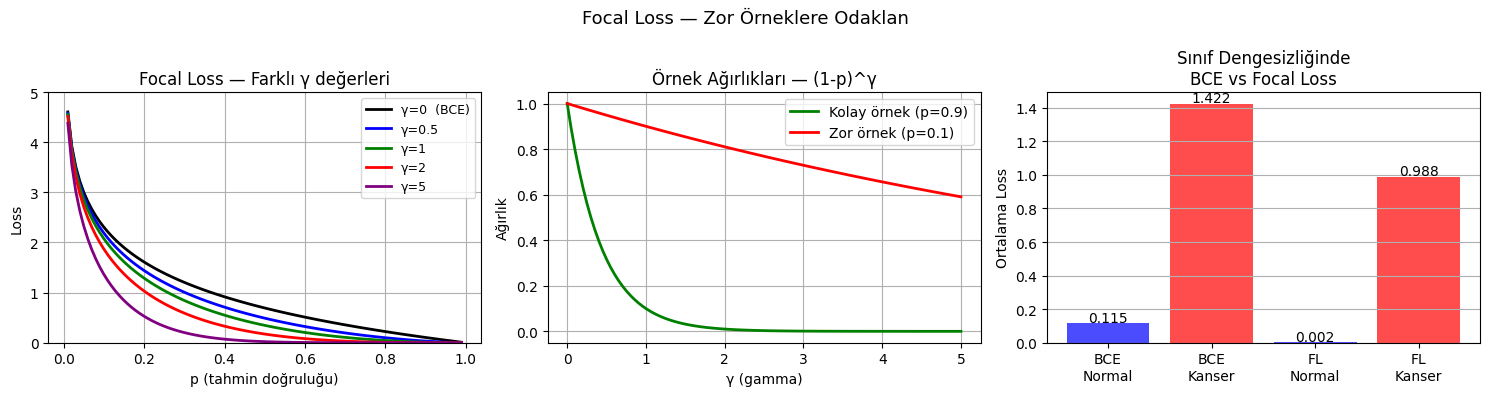

BCE: Normal loss=0.115, Kanser loss=1.422
FL:  Normal loss=0.002, Kanser loss=0.988

Focal Loss normal örneklerin ağırlığını 0.00x azaltıyor!
Model böylece kanser örneklerine daha çok odaklanıyor.


In [6]:
# FOCAL LOSS — Sınıf Dengesizliği Problemi
#
# Problem: 1000 görüntünün 990'ı "normal", 10'u "kanser"
# Model "hep normal de" derse %99 doğruluk ama işe yaramaz!
#
# Focal Loss: Kolay örnekleri görmezden gel, zor örneklere odaklan
# FL = -(1-p)^γ * log(p)
# γ (gamma) = 0 → standart BCE
# γ = 2 → kolay örneklerin ağırlığı çok azalır

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

p = np.linspace(0.01, 0.99, 100)

# Focal Loss farklı gamma değerleri için
gammas = [0, 0.5, 1, 2, 5]
renkler_fl = ['black', 'blue', 'green', 'red', 'purple']

for gamma, renk in zip(gammas, renkler_fl):
    fl = -(1-p)**gamma * np.log(p)
    axes[0].plot(p, fl, color=renk, linewidth=2,
                label=f'γ={gamma}{"  (BCE)" if gamma==0 else ""}')

axes[0].set_title("Focal Loss — Farklı γ değerleri")
axes[0].set_xlabel("p (tahmin doğruluğu)")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 5)
axes[0].grid(True)

# Kolay vs Zor örnek ağırlıkları
p_kolay = 0.9   # Model zaten doğru biliyor
p_zor = 0.1     # Model çok yanılıyor

gammas_range = np.linspace(0, 5, 100)
agirlik_kolay = (1 - p_kolay)**gammas_range
agirlik_zor = (1 - p_zor)**gammas_range

axes[1].plot(gammas_range, agirlik_kolay, 'g-',
             linewidth=2, label=f'Kolay örnek (p={p_kolay})')
axes[1].plot(gammas_range, agirlik_zor, 'r-',
             linewidth=2, label=f'Zor örnek (p={p_zor})')
axes[1].set_title("Örnek Ağırlıkları — (1-p)^γ")
axes[1].set_xlabel("γ (gamma)")
axes[1].set_ylabel("Ağırlık")
axes[1].legend()
axes[1].grid(True)

# Sınıf dengesizliği simülasyonu
np.random.seed(42)
n_normal = 990
n_kanser = 10

# BCE ile ağırlıklar
bce_normal = -np.log(np.random.uniform(0.8, 0.99, n_normal))
bce_kanser = -np.log(np.random.uniform(0.1, 0.4, n_kanser))

# Focal Loss ile ağırlıklar (gamma=2)
p_normal = np.random.uniform(0.8, 0.99, n_normal)
p_kanser = np.random.uniform(0.1, 0.4, n_kanser)
fl_normal = -(1-p_normal)**2 * np.log(p_normal)
fl_kanser = -(1-p_kanser)**2 * np.log(p_kanser)

kategoriler_bar = ['BCE\nNormal', 'BCE\nKanser', 'FL\nNormal', 'FL\nKanser']
değerler_bar = [bce_normal.mean(), bce_kanser.mean(),
                fl_normal.mean(), fl_kanser.mean()]
renkler_b = ['blue', 'red', 'blue', 'red']
alpha_b = [0.4, 0.4, 0.9, 0.9]

bars = axes[2].bar(kategoriler_bar, değerler_bar,
                   color=renkler_b, alpha=0.7)
for bar, val in zip(bars, değerler_bar):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10)
axes[2].set_title("Sınıf Dengesizliğinde\nBCE vs Focal Loss")
axes[2].set_ylabel("Ortalama Loss")
axes[2].grid(True, axis='y')

plt.suptitle("Focal Loss — Zor Örneklere Odaklan", fontsize=13)
plt.tight_layout()
plt.show()

print(f"BCE: Normal loss={bce_normal.mean():.3f}, Kanser loss={bce_kanser.mean():.3f}")
print(f"FL:  Normal loss={fl_normal.mean():.3f}, Kanser loss={fl_kanser.mean():.3f}")
print(f"\nFocal Loss normal örneklerin ağırlığını {fl_normal.mean()/fl_kanser.mean():.2f}x azaltıyor!")
print("Model böylece kanser örneklerine daha çok odaklanıyor.")

LOSS FONKSİYONU SEÇME REHBERİ
Problem                Loss                   Neden?
--------------------   --------------------   --------------------
Regresyon              MSE                    Gaussian gürültü varsayımı
Regresyon              MAE                    Aykırı değer varsa
Regresyon              Huber                  MSE+MAE dengesi
Binary sınıf.          BCE                    Bernoulli MLE
Çok sınıflı            Cross Entropy          Categorical MLE
Dengesiz sınıf         Focal Loss             Zor örneklere odak
Dil modeli             Cross Entropy          Token olasılıkları
GAN                    BCE                    Gerçek/sahte 0-1

ÖZET — Türetim Zinciri

Veri dağılımı varsay
        ↓
Likelihood fonksiyonu yaz: P(y|x,w)
        ↓
Log-likelihood al: log P(y|x,w)
        ↓
Negatif yap (minimize etmek için): -log P(y|x,w)
        ↓
Loss fonksiyonu!

- Gaussian → MSE
- Bernoulli → BCE  
- Categorical → Cross Entropy
- Laplace → MAE



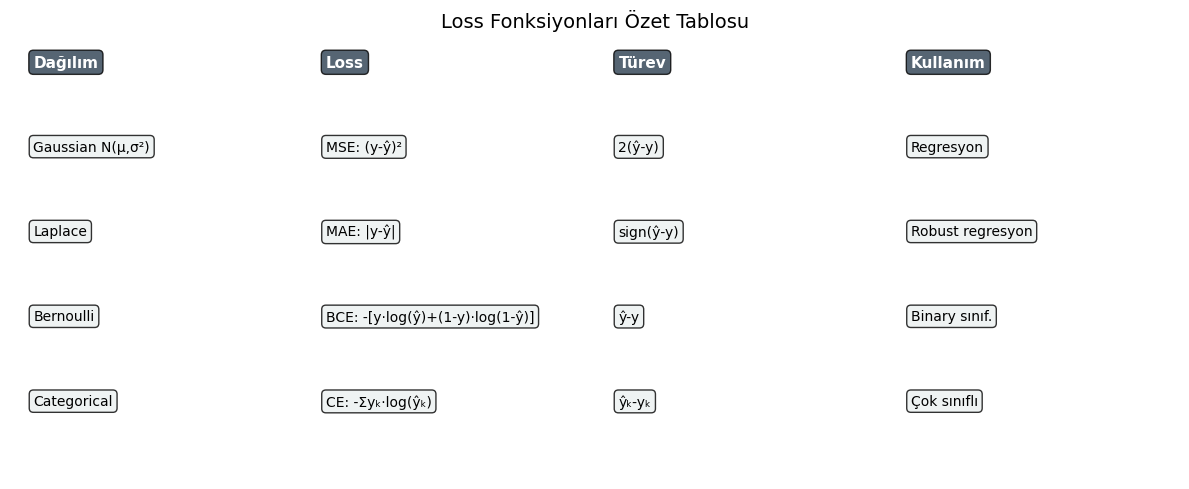

In [7]:
# HANGİ PROBLEMDE HANGİ LOSS?

print("=" * 65)
print("LOSS FONKSİYONU SEÇME REHBERİ")
print("=" * 65)

tablo = [
    ("Problem",          "Loss",              "Neden?"),
    ("-" * 20,           "-" * 20,            "-" * 20),
    ("Regresyon",        "MSE",               "Gaussian gürültü varsayımı"),
    ("Regresyon",        "MAE",               "Aykırı değer varsa"),
    ("Regresyon",        "Huber",             "MSE+MAE dengesi"),
    ("Binary sınıf.",    "BCE",               "Bernoulli MLE"),
    ("Çok sınıflı",      "Cross Entropy",     "Categorical MLE"),
    ("Dengesiz sınıf",   "Focal Loss",        "Zor örneklere odak"),
    ("Dil modeli",       "Cross Entropy",     "Token olasılıkları"),
    ("GAN",              "BCE",               "Gerçek/sahte 0-1"),
]

for satır in tablo:
    print(f"{satır[0]:22s} {satır[1]:22s} {satır[2]}")

print("\n" + "=" * 65)
print("ÖZET — Türetim Zinciri")
print("=" * 65)
print("""
Veri dağılımı varsay
        ↓
Likelihood fonksiyonu yaz: P(y|x,w)
        ↓
Log-likelihood al: log P(y|x,w)
        ↓
Negatif yap (minimize etmek için): -log P(y|x,w)
        ↓
Loss fonksiyonu!

- Gaussian → MSE
- Bernoulli → BCE  
- Categorical → Cross Entropy
- Laplace → MAE
""")

# Görsel özet
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

satırlar = [
    ["Dağılım", "Loss", "Türev", "Kullanım"],
    ["Gaussian N(μ,σ²)", "MSE: (y-ŷ)²", "2(ŷ-y)", "Regresyon"],
    ["Laplace", "MAE: |y-ŷ|", "sign(ŷ-y)", "Robust regresyon"],
    ["Bernoulli", "BCE: -[y·log(ŷ)+(1-y)·log(1-ŷ)]",
     "ŷ-y", "Binary sınıf."],
    ["Categorical", "CE: -Σyₖ·log(ŷₖ)", "ŷₖ-yₖ", "Çok sınıflı"],
]

renkler_tablo = ['#2c3e50', '#2980b9', '#27ae60', '#e74c3c', '#8e44ad']

for i, satır in enumerate(satırlar):
    for j, hücre in enumerate(satır):
        renk = renkler_tablo[i] if i == 0 else '#ecf0f1'
        metin_renk = 'white' if i == 0 else 'black'
        ax.text(j * 0.25 + 0.02, 1 - i * 0.2, hücre,
               transform=ax.transAxes,
               fontsize=10 if i > 0 else 11,
               fontweight='bold' if i == 0 else 'normal',
               color=metin_renk,
               verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.3',
                        facecolor=renk, alpha=0.8))

plt.title("Loss Fonksiyonları Özet Tablosu", fontsize=14, pad=20)
plt.tight_layout()
plt.show()